# Day 2: Retail Basket Association Analyser

**Industry:** Retail / E-commerce  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · numpy · groupby · association rules · matplotlib

**Data:** UCI Online Retail Dataset — real UK e-commerce transactions 2010–2011 (541,909 rows)

---

## Who uses this
A **category manager** deciding which products to co-locate on shelves, bundle in promotions, or cross-recommend on a website. Instead of guessing, they use transaction data to find which products are genuinely bought together.

## Problem
Retailers leave significant cross-sell revenue on the table because product placement and recommendation decisions are made by gut feel rather than transaction data. A product pair with high lift means customers who buy one are much more likely to buy the other — that is a promotion waiting to happen.

## What we build
1. Load and inspect the raw retail transaction data
2. Clean: remove cancellations, nulls, and bad rows
3. Build a basket matrix — one row per order, one column per product
4. Calculate support, confidence, and lift for every product pair
5. Rank top 20 pairs by lift
6. Visualise and export results

## Key metric: Lift
**Lift > 1** means the two products are bought together more than chance would predict.  
**Lift = 3** means customers are 3x more likely to buy Product B if they already have Product A in their basket.  
This is what drives product bundling and recommendation engine logic at retailers like Amazon.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from itertools import combinations
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load the Data

The dataset is an Excel file — pandas handles this with `read_excel`. We immediately check shape, columns, and the first few rows. Always do this before touching the data — never assume you know what is in it.

In [2]:
df = pd.read_excel('Online_Retail.xlsx')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Date range: {df["InvoiceDate"].min()} to {df["InvoiceDate"].max()}')
print(f'Countries: {df["Country"].nunique()}')
df.head(5)

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Countries: 38


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Step 3 — Inspect Data Quality

Before cleaning we profile the data — how many nulls, what do cancellations look like, what are the value distributions.

In [4]:
print('=== Null counts ===')
print(df.isnull().sum())

print('\n=== Sample InvoiceNo values ===')
print(df['InvoiceNo'].astype(str).head(10).tolist())

print('\n=== Quantity stats ===')
print(df['Quantity'].describe().round(2))

print('\n=== Top 5 countries by transaction count ===')
print(df['Country'].value_counts().head())

cancellations = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'\nCancelled orders: {len(cancellations):,} ({len(cancellations)/len(df)*100:.1f}%)')

=== Null counts ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=== Sample InvoiceNo values ===
['536365', '536365', '536365', '536365', '536365', '536365', '536365', '536366', '536366', '536367']

=== Quantity stats ===
count    541909.00
mean          9.55
std         218.08
min      -80995.00
25%           1.00
50%           3.00
75%          10.00
max       80995.00
Name: Quantity, dtype: float64

=== Top 5 countries by transaction count ===
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Name: count, dtype: int64

Cancelled orders: 9,288 (1.7%)


## Step 4 — Clean the Data

Several issues to fix:
- **Cancellations** — InvoiceNo starting with 'C' are returns, not purchases. Remove them.
- **Null CustomerID** — we need customer identity for basket analysis. Drop these.
- **Negative quantities** — returns and adjustments. Remove.
- **Focus on UK** — largest market, most representative basket behaviour.

In [5]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df.dropna(subset=['CustomerID', 'Description'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df_uk = df[df['Country'] == 'United Kingdom'].copy()
df_uk['Description'] = df_uk['Description'].str.strip()
df_uk['Revenue'] = df_uk['Quantity'] * df_uk['UnitPrice']

print(f'Clean UK rows: {len(df_uk):,}')
print(f'Unique invoices (baskets): {df_uk["InvoiceNo"].nunique():,}')
print(f'Unique products: {df_uk["Description"].nunique():,}')
print(f'Total UK revenue: £{df_uk["Revenue"].sum():,.2f}')
df_uk.head(3)

Clean UK rows: 354,321
Unique invoices (baskets): 16,646
Unique products: 3,833
Total UK revenue: £7,308,391.55


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


## Step 5 — Build the Basket Matrix

We group by `InvoiceNo` and collect all products per invoice into a list. We focus on the **top 100 most frequent products** to keep computation fast and results meaningful.

In [6]:
top_products = (
    df_uk.groupby('Description')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
    .head(100)
    .index.tolist()
)

print(f'Top 5 most frequent products: {top_products[:5]}')

df_top = df_uk[df_uk['Description'].isin(top_products)]

baskets = (
    df_top.groupby('InvoiceNo')['Description']
    .apply(list)
    .reset_index()
)

baskets = baskets[baskets['Description'].apply(len) >= 2]

print(f'Baskets with 2+ items: {len(baskets):,}')
print(f'\nSample basket: {baskets.iloc[0]["Description"]}')

Top 5 most frequent products: ['WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', 'REGENCY CAKESTAND 3 TIER', 'ASSORTED COLOUR BIRD ORNAMENT', 'PARTY BUNTING']
Baskets with 2+ items: 10,909

Sample basket: ['ASSORTED COLOUR BIRD ORNAMENT', 'HOME BUILDING BLOCK WORD', 'LOVE BUILDING BLOCK WORD', 'DOORMAT NEW ENGLAND']


## Step 6 — Calculate Support, Confidence and Lift

The three standard association rule metrics:

- **Support** = how often the pair appears / total baskets
- **Confidence** = P(B | A) — given A is in basket, how often is B also there?
- **Lift** = confidence / P(B alone). The key metric. Lift > 1 means the pair occurs more than by chance.

In [7]:
total_baskets = len(baskets)

product_counts = Counter()
pair_counts = Counter()

for _, row in baskets.iterrows():
    items = list(set(row['Description']))
    for item in items:
        product_counts[item] += 1
    for pair in combinations(sorted(items), 2):
        pair_counts[pair] += 1

print(f'Total baskets analysed: {total_baskets:,}')
print(f'Unique product pairs found: {len(pair_counts):,}')

rules = []
min_support_count = 10

for (item_a, item_b), count in pair_counts.items():
    if count < min_support_count:
        continue
    support  = count / total_baskets
    conf_ab  = count / product_counts[item_a]
    conf_ba  = count / product_counts[item_b]
    lift     = support / ((product_counts[item_a] / total_baskets) *
                          (product_counts[item_b] / total_baskets))
    rules.append({
        'product_a':     item_a,
        'product_b':     item_b,
        'support':       round(support, 4),
        'confidence_ab': round(conf_ab, 4),
        'confidence_ba': round(conf_ba, 4),
        'lift':          round(lift, 2),
        'pair_count':    count
    })

rules_df = pd.DataFrame(rules).sort_values('lift', ascending=False)

print(f'\nAssociation rules generated: {len(rules_df):,}')
print('\n=== Top 10 pairs by lift ===')
print(rules_df.head(10)[['product_a','product_b','lift','support','confidence_ab']].to_string())

Total baskets analysed: 10,909
Unique product pairs found: 4,950

Association rules generated: 4,942

=== Top 10 pairs by lift ===
                              product_a                         product_b   lift  support  confidence_ab
1893    GREEN REGENCY TEACUP AND SAUCER    PINK REGENCY TEACUP AND SAUCER  15.03   0.0370         0.6656
2052     PINK REGENCY TEACUP AND SAUCER   ROSES REGENCY TEACUP AND SAUCER  13.03   0.0351         0.7930
525     GREEN REGENCY TEACUP AND SAUCER   ROSES REGENCY TEACUP AND SAUCER  12.88   0.0436         0.7842
4188        LARGE WHITE HEART OF WICKER       SMALL WHITE HEART OF WICKER  10.97   0.0254         0.5630
3806  GARDENERS KNEELING PAD CUP OF TEA  GARDENERS KNEELING PAD KEEP CALM  10.93   0.0420         0.7387
657           CHARLOTTE BAG SUKI DESIGN       RED RETROSPOT CHARLOTTE BAG   9.85   0.0244         0.5418
109          ALARM CLOCK BAKELIKE GREEN          ALARM CLOCK BAKELIKE RED   9.84   0.0416         0.6726
124          CHOCOLATE HOT WA

## Step 7 — Business Insight: Revenue Opportunity

Lift tells us statistical association. But what makes a category manager act is **revenue opportunity** — how much could a promotion on this pair generate?

In [8]:
avg_revenue = (
    df_uk.groupby('Description')['Revenue']
    .mean()
    .round(2)
)

top20 = rules_df.head(20).copy()
top20['avg_rev_a'] = top20['product_a'].map(avg_revenue).fillna(0).round(2)
top20['avg_rev_b'] = top20['product_b'].map(avg_revenue).fillna(0).round(2)
top20['combined_avg_rev'] = (top20['avg_rev_a'] + top20['avg_rev_b']).round(2)
top20['revenue_opportunity_gbp'] = (
    top20['pair_count'] * top20['combined_avg_rev'] * (top20['lift'] / 10)
).round(2)

print('=== Top 20 product pairs — lift + revenue opportunity ===')
print(top20[['product_a','product_b','lift','pair_count','combined_avg_rev','revenue_opportunity_gbp']].to_string())

=== Top 20 product pairs — lift + revenue opportunity ===
                              product_a                           product_b   lift  pair_count  combined_avg_rev  revenue_opportunity_gbp
1893    GREEN REGENCY TEACUP AND SAUCER      PINK REGENCY TEACUP AND SAUCER  15.03         404             47.81                 29030.81
2052     PINK REGENCY TEACUP AND SAUCER     ROSES REGENCY TEACUP AND SAUCER  13.03         383             53.30                 26599.31
525     GREEN REGENCY TEACUP AND SAUCER     ROSES REGENCY TEACUP AND SAUCER  12.88         476             52.65                 32279.08
4188        LARGE WHITE HEART OF WICKER         SMALL WHITE HEART OF WICKER  10.97         277             26.20                  7961.37
3806  GARDENERS KNEELING PAD CUP OF TEA    GARDENERS KNEELING PAD KEEP CALM  10.93         458             31.38                 15708.64
657           CHARLOTTE BAG SUKI DESIGN         RED RETROSPOT CHARLOTTE BAG   9.85         266             21.75  

## Step 8 — Visualise

Three panels:
- **Top-left:** Top 20 pairs by lift
- **Top-right:** Support vs Lift scatter — shows which pairs are both frequent AND strongly associated
- **Bottom:** Revenue opportunity for top 10 pairs

Chart saved as basket_analysis.png


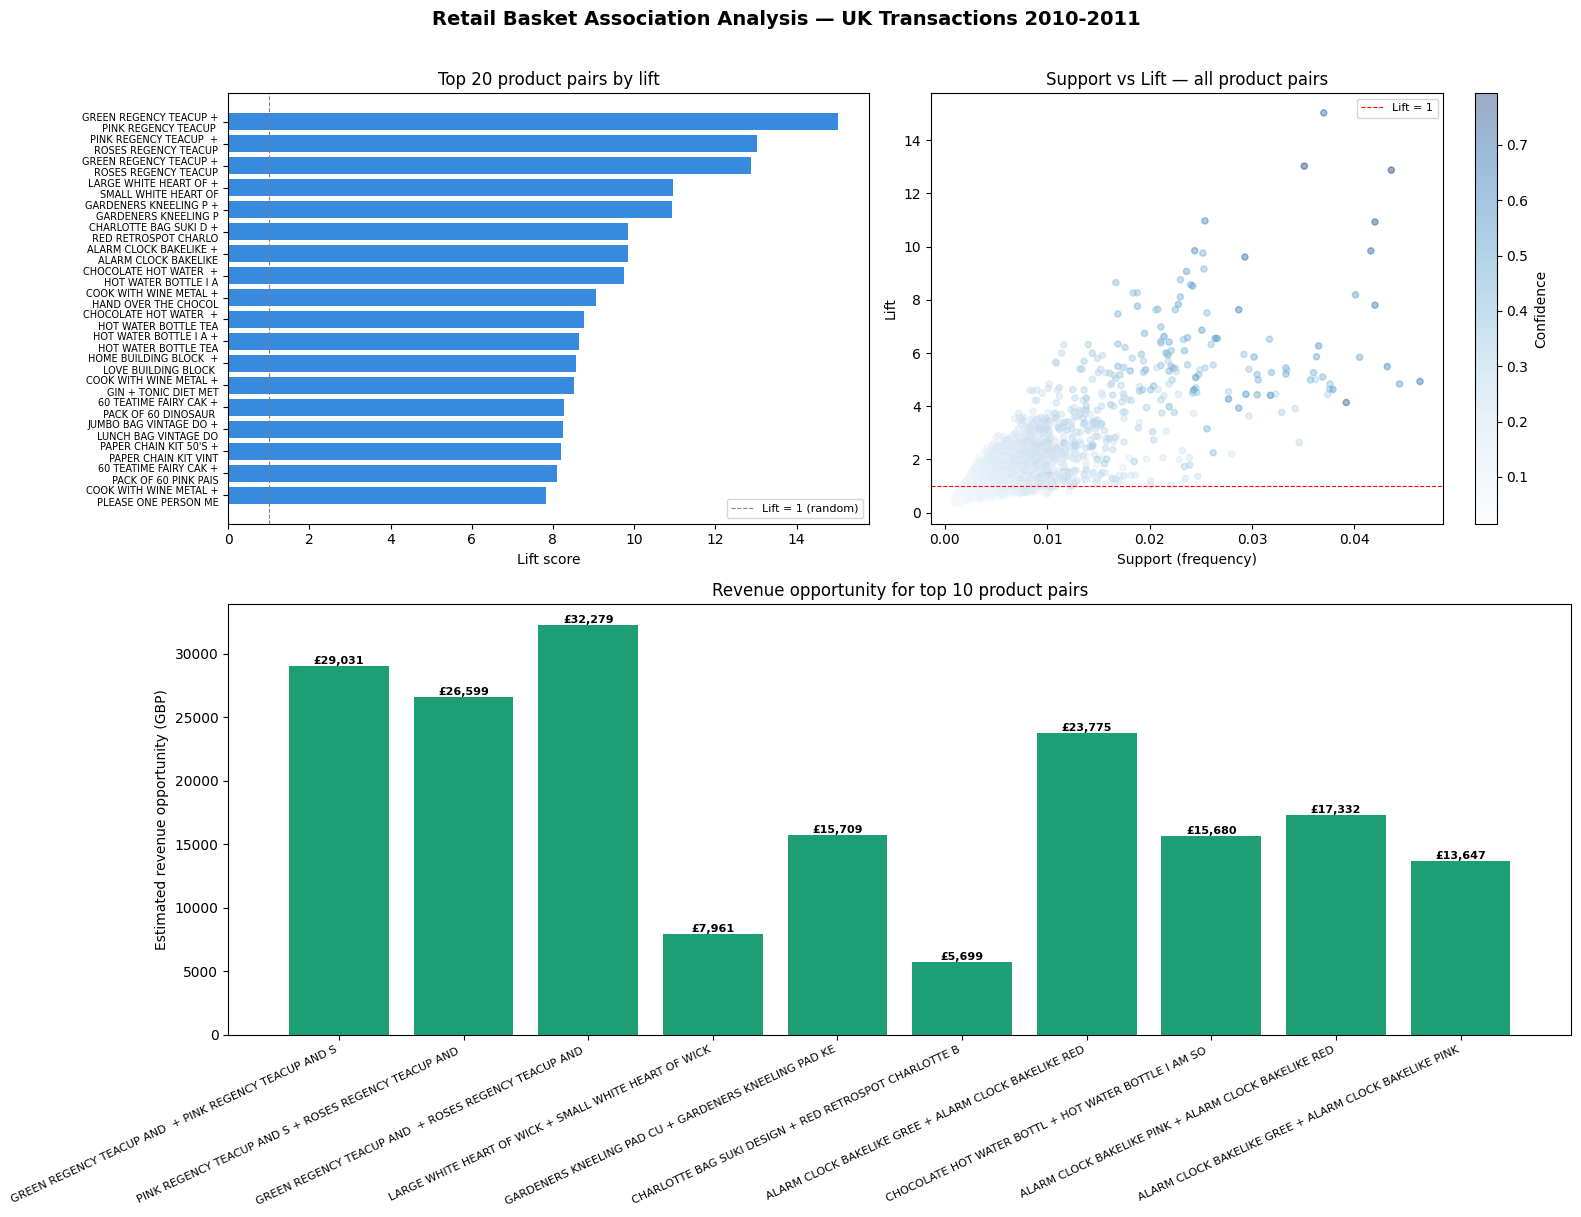

In [9]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Retail Basket Association Analysis — UK Transactions 2010-2011',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1 — Top 20 pairs by lift
ax1 = fig.add_subplot(2, 2, 1)
top20_plot = top20.head(20).copy()
top20_plot['pair_label'] = top20_plot['product_a'].str[:20] + ' +\n' + top20_plot['product_b'].str[:20]
ax1.barh(top20_plot['pair_label'], top20_plot['lift'], color='#378ADD')
ax1.set_xlabel('Lift score')
ax1.set_title('Top 20 product pairs by lift')
ax1.invert_yaxis()
ax1.axvline(1, color='gray', linestyle='--', linewidth=0.8, label='Lift = 1 (random)')
ax1.legend(fontsize=8)
ax1.tick_params(axis='y', labelsize=7)

# Panel 2 — Support vs Lift scatter
ax2 = fig.add_subplot(2, 2, 2)
scatter = ax2.scatter(
    rules_df['support'],
    rules_df['lift'],
    alpha=0.4,
    c=rules_df['confidence_ab'],
    cmap='Blues',
    s=20
)
plt.colorbar(scatter, ax=ax2, label='Confidence')
ax2.set_xlabel('Support (frequency)')
ax2.set_ylabel('Lift')
ax2.set_title('Support vs Lift — all product pairs')
ax2.axhline(1, color='red', linestyle='--', linewidth=0.8, label='Lift = 1')
ax2.legend(fontsize=8)

# Panel 3 — Revenue opportunity top 10
ax3 = fig.add_subplot(2, 1, 2)
top10_rev = top20.head(10).copy()
top10_rev['pair_label'] = top10_rev['product_a'].str[:25] + ' + ' + top10_rev['product_b'].str[:25]
bars = ax3.bar(range(len(top10_rev)), top10_rev['revenue_opportunity_gbp'], color='#1D9E75')
ax3.set_xticks(range(len(top10_rev)))
ax3.set_xticklabels(top10_rev['pair_label'], rotation=25, ha='right', fontsize=8)
ax3.set_ylabel('Estimated revenue opportunity (GBP)')
ax3.set_title('Revenue opportunity for top 10 product pairs')
for bar, val in zip(bars, top10_rev['revenue_opportunity_gbp']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'£{val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('basket_analysis.png', dpi=150, bbox_inches='tight')
print('Chart saved as basket_analysis.png')
plt.show()

## Step 9 — Export Results

In [10]:
import os
os.makedirs('output', exist_ok=True)

rules_df.to_csv('output/all_association_rules.csv', index=False)
top20.to_csv('output/top20_pairs_with_revenue.csv', index=False)

print('Results exported to output/ folder')
print('\n' + '='*55)
print('BUSINESS INSIGHT SUMMARY')
print('='*55)
print(f'Total baskets analysed:        {total_baskets:,}')
print(f'Total association rules found: {len(rules_df):,}')
print(f'Rules with lift > 2:           {len(rules_df[rules_df["lift"] > 2]):,}')
print(f'Rules with lift > 5:           {len(rules_df[rules_df["lift"] > 5]):,}')
print()
print('Top 3 product pairs to promote:')
for i, (_, row) in enumerate(rules_df.head(3).iterrows()):
    print(f'  {i+1}. {row["product_a"][:35]} + {row["product_b"][:35]}')
    print(f'     Lift: {row["lift"]}x — customers are {row["lift"]}x more likely to buy these together')
    print()
print('Recommendation: Bundle or co-locate the top 3 pairs.')
print(f'Highest revenue opportunity: {top20.iloc[0]["product_a"]} + {top20.iloc[0]["product_b"]}')
print(f'Estimated opportunity: £{top20.iloc[0]["revenue_opportunity_gbp"]:,.2f}')

Results exported to output/ folder

BUSINESS INSIGHT SUMMARY
Total baskets analysed:        10,909
Total association rules found: 4,942
Rules with lift > 2:           655
Rules with lift > 5:           104

Top 3 product pairs to promote:
  1. GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY TEACUP AND SAUCER
     Lift: 15.03x — customers are 15.03x more likely to buy these together

  2. PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER
     Lift: 13.03x — customers are 13.03x more likely to buy these together

  3. GREEN REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER
     Lift: 12.88x — customers are 12.88x more likely to buy these together

Recommendation: Bundle or co-locate the top 3 pairs.
Highest revenue opportunity: GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY TEACUP AND SAUCER
Estimated opportunity: £29,030.81


## Summary

### What we built
A full basket association analysis pipeline on 541,909 real UK retail transactions — from raw Excel to actionable product pair recommendations with revenue estimates.

### Skills practised
- `pandas` — read_excel, groupby, apply, merge, dropna, filtering
- `numpy` — vectorised calculations
- `itertools.combinations` — generating all product pairs per basket
- `collections.Counter` — fast frequency counting
- `matplotlib` — subplots, scatter with colormap, annotated bar charts
- Association rule metrics — support, confidence, lift built from scratch

### Business context
This type of analysis powers Amazon's 'frequently bought together' feature and supermarket shelf placement decisions. 

### Key findings

- Strongest pair (highest lift): GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY TEACUP AND SAUCER
- Highest revenue opportunity pair: £29,030.81
- Rules with lift > 2: 655
- Total rules found: 4,942